In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Load fit parameters and extract numeric power
df = pd.read_csv("/Users/snip/Documents/MEOP/power_dependence_plots/fit_parameters_all_files.csv")

# Extract numeric power (e.g., "3W" → 3)
df["power_W"] = df["power"].str.replace("W", "").astype(int)

# Split by cell
df_C8 = df[df["cell"] == "C8"].copy()
df_C9 = df[df["cell"] == "C9"].copy()

print(f"Total files: {len(df)}")
print(f"  C8: {len(df_C8)} files, powers: {sorted(df_C8['power_W'].unique())} W")
print(f"  C9: {len(df_C9)} files, powers: {sorted(df_C9['power_W'].unique())} W")

# Compute mean ± std for each power level (averaging over datagrabs)
df_C8_avg = df_C8.groupby("power_W").agg(
    P0_mean=("P0", "mean"), P0_std=("P0", "std"),
    P0_err_mean=("P0_err", "mean"),
    tau_b_mean=("tau_b", "mean"), tau_b_std=("tau_b", "std"),
    tau_b_err_mean=("tau_b_err", "mean"),
    tau_mean=("tau", "mean"), tau_std=("tau", "std"),
    tau_err_mean=("tau_err", "mean"),
    P_plateau_mean=("P_plateau", "mean"), P_plateau_std=("P_plateau", "std"),
    P_plateau_err_mean=("P_plateau_err", "mean"),
    n_files=("filename", "count"),
).reset_index()

df_C9_avg = df_C9.groupby("power_W").agg(
    P0_mean=("P0", "mean"), P0_std=("P0", "std"),
    P0_err_mean=("P0_err", "mean"),
    tau_b_mean=("tau_b", "mean"), tau_b_std=("tau_b", "std"),
    tau_b_err_mean=("tau_b_err", "mean"),
    tau_mean=("tau", "mean"), tau_std=("tau", "std"),
    tau_err_mean=("tau_err", "mean"),
    P_plateau_mean=("P_plateau", "mean"), P_plateau_std=("P_plateau", "std"),
    P_plateau_err_mean=("P_plateau_err", "mean"),
    n_files=("filename", "count"),
).reset_index()

print("\nC8 averaged:")
print(df_C8_avg[["power_W", "P0_mean", "tau_b_mean", "tau_mean", "P_plateau_mean", "n_files"]].to_string(index=False))
print("\nC9 averaged:")
print(df_C9_avg[["power_W", "P0_mean", "tau_b_mean", "tau_mean", "P_plateau_mean", "n_files"]].to_string(index=False))

Total files: 37
  C8: 18 files, powers: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] W
  C9: 19 files, powers: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] W

C8 averaged:
 power_W   P0_mean  tau_b_mean   tau_mean  P_plateau_mean  n_files
       3 46.618311   16.923275 109.690486       53.411621        3
       4 46.641759   15.576155 117.695845       55.777814        3
       5 49.696533   12.133667 102.380555       55.273722        3
       6 48.654306   12.553671 101.343244       56.415134        3
       7 49.920123   11.218777  90.273128       55.862203        3
       8 48.745525   16.303132 100.368679       55.427056        3

C9 averaged:
 power_W   P0_mean  tau_b_mean   tau_mean  P_plateau_mean  n_files
       3 48.084737   33.241282 102.994415       56.163509        4
       4 58.734515   21.621232  98.636834       66.826836        3
       5 58.302272   21.546209 103.836727       68.765464        3
       6 

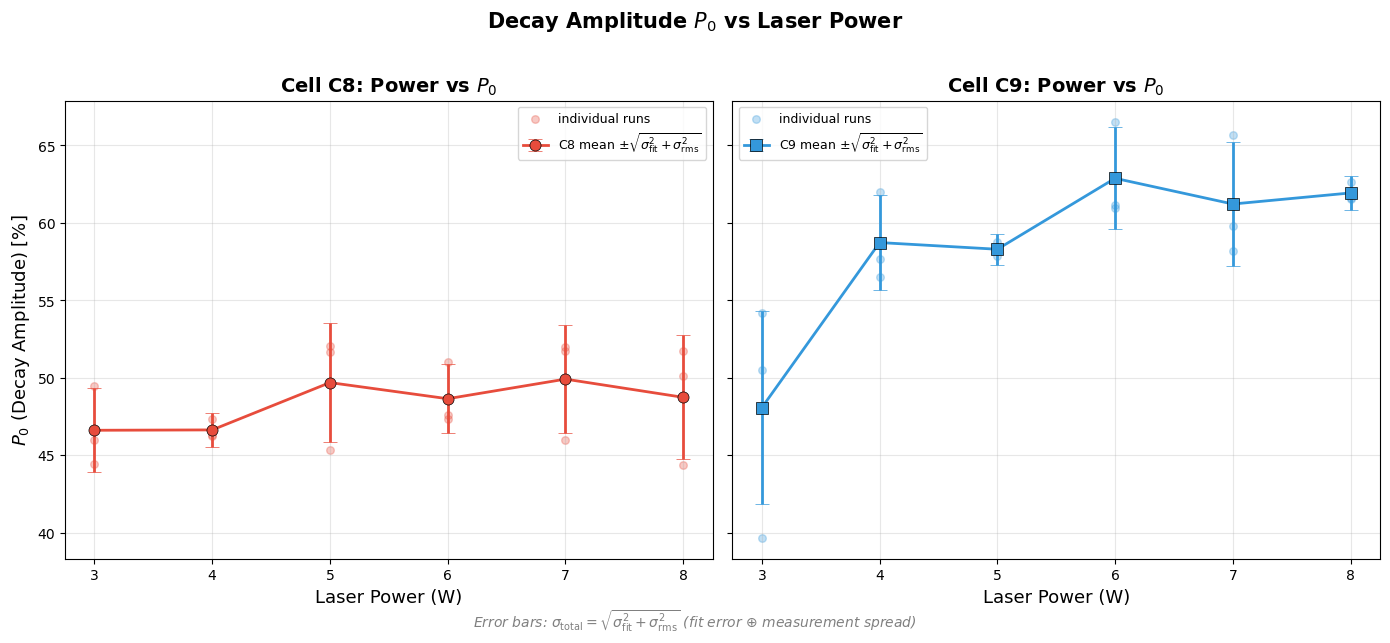

In [ ]:
# ============================================================================
# Plot 1: Power vs P0 (Decay Amplitude) — C8 and C9 separate
# ============================================================================
# Total error = quadrature sum of independent contributions:
#   σ_total = sqrt( σ_fit² + σ_rms² )
#   σ_fit = mean fit error from ROOT (P0_err averaged over datagrabs)
#   σ_rms = std of P0 across repeated datagrabs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- C8 ---
err_C8_P0 = np.sqrt(df_C8_avg["P0_err_mean"]**2 + df_C8_avg["P0_std"].fillna(0)**2)
ax1.errorbar(df_C8_avg["power_W"], df_C8_avg["P0_mean"], yerr=err_C8_P0,
             fmt='o-', color='#e74c3c', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5,
             label=r'C8 mean $\pm\sqrt{\sigma_{\rm fit}^2 + \sigma_{\rm rms}^2}$')
ax1.scatter(df_C8["power_W"], df_C8["P0"], color='#e74c3c', alpha=0.3, s=30,
            zorder=0, label='individual runs')
ax1.set_xlabel("Laser Power (W)", fontsize=13)
ax1.set_ylabel("$P_0$ (Decay Amplitude) [%]", fontsize=13)
ax1.set_title("Cell C8: Power vs $P_0$", fontsize=14, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(sorted(df_C8["power_W"].unique()))


# --- C9 ---
err_C9_P0 = np.sqrt(df_C9_avg["P0_err_mean"]**2 + df_C9_avg["P0_std"].fillna(0)**2)
ax2.errorbar(df_C9_avg["power_W"], df_C9_avg["P0_mean"], yerr=err_C9_P0,
             fmt='s-', color='#3498db', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5,
             label=r'C9 mean $\pm\sqrt{\sigma_{\rm fit}^2 + \sigma_{\rm rms}^2}$')
ax2.scatter(df_C9["power_W"], df_C9["P0"], color='#3498db', alpha=0.3, s=30,
            zorder=0, label='individual runs')
ax2.set_xlabel("Laser Power (W)", fontsize=13)
ax2.set_title("Cell C9: Power vs $P_0$", fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(sorted(df_C9["power_W"].unique()))

fig.suptitle("Decay Amplitude $P_0$ vs Laser Power", fontsize=15, fontweight='bold', y=1.02)
fig.text(0.5, -0.01,
         r"Error bars: $\sigma_{\rm total} = \sqrt{\sigma_{\rm fit}^2 + \sigma_{\rm rms}^2}$ (fit error $\oplus$ measurement spread)",
         ha='center', fontsize=10, style='italic', color='gray')
plt.tight_layout()
plt.savefig("/Users/snip/Documents/MEOP/power_dependence_plots/power_vs_P0.png", dpi=150, bbox_inches='tight')
plt.show()

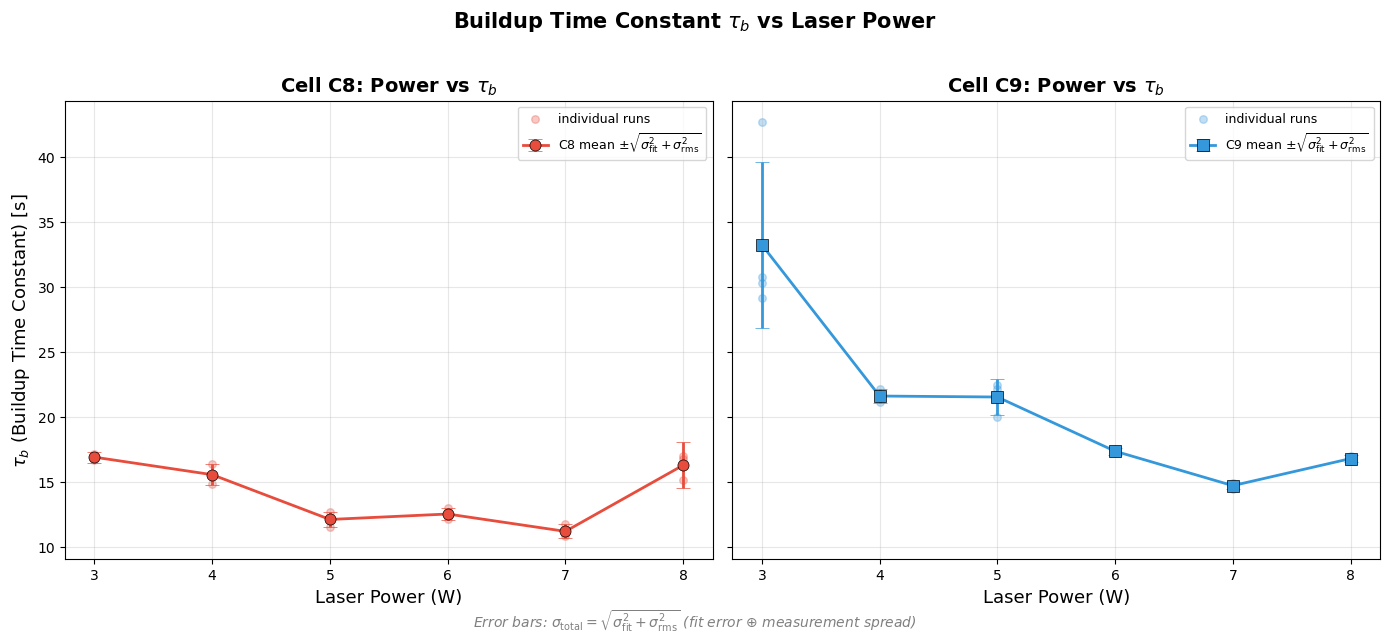

In [19]:
# ============================================================================
# Plot 2: Power vs tau_b (Buildup Time Constant) — C8 and C9 separate
# ============================================================================
# σ_total = sqrt( σ_fit² + σ_rms² )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- C8 ---
err_C8_tau = np.sqrt(df_C8_avg["tau_b_err_mean"]**2 + df_C8_avg["tau_b_std"].fillna(0)**2)
ax1.errorbar(df_C8_avg["power_W"], df_C8_avg["tau_b_mean"], yerr=err_C8_tau,
             fmt='o-', color='#e74c3c', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5,
             label=r'C8 mean $\pm\sqrt{\sigma_{\rm fit}^2 + \sigma_{\rm rms}^2}$')
ax1.scatter(df_C8["power_W"], df_C8["tau_b"], color='#e74c3c', alpha=0.3, s=30,
            zorder=0, label='individual runs')
ax1.set_xlabel("Laser Power (W)", fontsize=13)
ax1.set_ylabel(r"$\tau_b$ (Buildup Time Constant) [s]", fontsize=13)
ax1.set_title(r"Cell C8: Power vs $\tau_b$", fontsize=14, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(sorted(df_C8["power_W"].unique()))

# --- C9 ---
err_C9_tau = np.sqrt(df_C9_avg["tau_b_err_mean"]**2 + df_C9_avg["tau_b_std"].fillna(0)**2)
ax2.errorbar(df_C9_avg["power_W"], df_C9_avg["tau_b_mean"], yerr=err_C9_tau,
             fmt='s-', color='#3498db', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5,
             label=r'C9 mean $\pm\sqrt{\sigma_{\rm fit}^2 + \sigma_{\rm rms}^2}$')
ax2.scatter(df_C9["power_W"], df_C9["tau_b"], color='#3498db', alpha=0.3, s=30,
            zorder=0, label='individual runs')
ax2.set_xlabel("Laser Power (W)", fontsize=13)
ax2.set_title(r"Cell C9: Power vs $\tau_b$", fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(sorted(df_C9["power_W"].unique()))

fig.suptitle(r"Buildup Time Constant $\tau_b$ vs Laser Power", fontsize=15, fontweight='bold', y=1.02)
fig.text(0.5, -0.01,
         r"Error bars: $\sigma_{\rm total} = \sqrt{\sigma_{\rm fit}^2 + \sigma_{\rm rms}^2}$ (fit error $\oplus$ measurement spread)",
         ha='center', fontsize=10, style='italic', color='gray')
plt.tight_layout()
plt.savefig("/Users/snip/Documents/MEOP/power_dependence_plots/power_vs_tau_b.png", dpi=150, bbox_inches='tight')
plt.show()

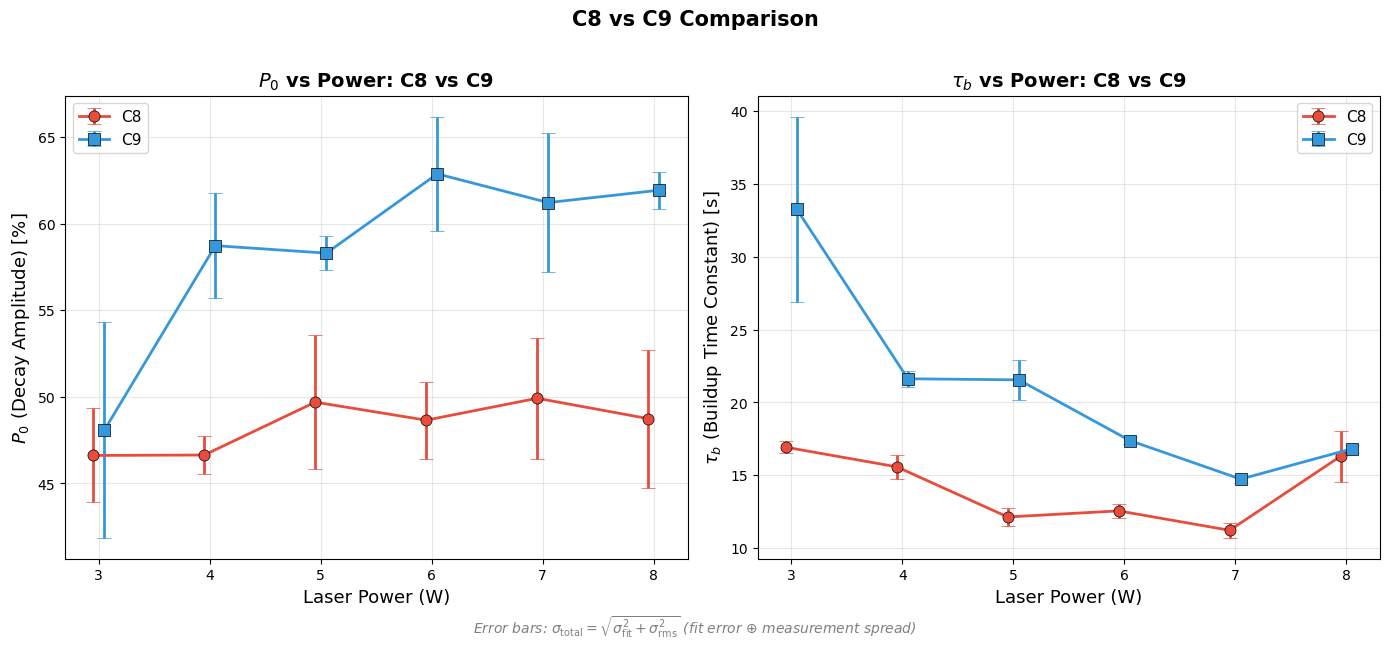

In [15]:
# ============================================================================
# Plot 3: Combined Overlay — C8 vs C9 on same axes
# ============================================================================
# σ_total = sqrt( σ_fit² + σ_rms² )  — independent errors added in quadrature

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

dx = 0.05  # x-offset to separate C8/C9 points

# --- P0 comparison ---
err_C8_P0 = np.sqrt(df_C8_avg["P0_err_mean"]**2 + df_C8_avg["P0_std"].fillna(0)**2)
err_C9_P0 = np.sqrt(df_C9_avg["P0_err_mean"]**2 + df_C9_avg["P0_std"].fillna(0)**2)

ax1.errorbar(df_C8_avg["power_W"] - dx, df_C8_avg["P0_mean"], yerr=err_C8_P0,
             fmt='o-', color='#e74c3c', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5, label='C8')
ax1.errorbar(df_C9_avg["power_W"] + dx, df_C9_avg["P0_mean"], yerr=err_C9_P0,
             fmt='s-', color='#3498db', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5, label='C9')
ax1.set_xlabel("Laser Power (W)", fontsize=13)
ax1.set_ylabel("$P_0$ (Decay Amplitude) [%]", fontsize=13)
ax1.set_title("$P_0$ vs Power: C8 vs C9", fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- tau_b comparison ---
err_C8_tau = np.sqrt(df_C8_avg["tau_b_err_mean"]**2 + df_C8_avg["tau_b_std"].fillna(0)**2)
err_C9_tau = np.sqrt(df_C9_avg["tau_b_err_mean"]**2 + df_C9_avg["tau_b_std"].fillna(0)**2)

ax2.errorbar(df_C8_avg["power_W"] - dx, df_C8_avg["tau_b_mean"], yerr=err_C8_tau,
             fmt='o-', color='#e74c3c', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5, label='C8')
ax2.errorbar(df_C9_avg["power_W"] + dx, df_C9_avg["tau_b_mean"], yerr=err_C9_tau,
             fmt='s-', color='#3498db', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5, label='C9')
ax2.set_xlabel("Laser Power (W)", fontsize=13)
ax2.set_ylabel(r"$\tau_b$ (Buildup Time Constant) [s]", fontsize=13)
ax2.set_title(r"$\tau_b$ vs Power: C8 vs C9", fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

fig.text(0.5, -0.02,
         r"Error bars: $\sigma_{\rm total} = \sqrt{\sigma_{\rm fit}^2 + \sigma_{\rm rms}^2}$ (fit error $\oplus$ measurement spread)",
         ha='center', fontsize=10, style='italic', color='gray')

fig.suptitle("C8 vs C9 Comparison", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("/Users/snip/Documents/MEOP/power_dependence_plots/C8_vs_C9_comparison.png", dpi=150, bbox_inches='tight')
plt.show()